In [1]:
# --- IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import time
import copy

# --- CONFIGURATION ---
BATCH_SIZE = 32
NUM_EPOCHS = 20  # Adjust as needed
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- 1. DATASET CLASS (For loading cached .pt files) ---
class MemoryCachedDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        self.samples = self.data['samples']
        self.classes = self.data['classes']
        self.class_to_idx = self.data['class_to_idx']

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


c:\Users\sreeh\miniconda3\envs\your_env_name\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:

# --- 2. LOAD DATA ---
# Ensure you have run the previous caching script to generate these .pt files!
try:
    train_dataset = MemoryCachedDataset("train_cache.pt")
    val_dataset = MemoryCachedDataset("val_cache.pt")
    test_dataset = MemoryCachedDataset("test_cache.pt")
    
    class_names = train_dataset.classes
    print(f"Classes: {class_names}")

    # Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
except FileNotFoundError:
    print("Error: Cache files not found. Please run the caching script first.")

# --- 3. MODEL SETUP (ResNet-34) ---
def initialize_model(num_classes):
    # Load pre-trained ResNet34
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    
    # Freeze early layers (Optional: often good for small datasets)
    # for param in model.parameters():
    #     param.requires_grad = False
    
    # Modify the final Fully Connected layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model.to(DEVICE)

model = initialize_model(len(class_names))

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Scheduler to reduce LR if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


Classes: ['Cysts_Structural', 'Dysarthia', 'Laryngitis', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']


In [3]:
import copy

def train_model_with_checkpoint(model, train_loader, val_loader, num_epochs=10, checkpoint_path="best_resnet34.pth"):
    since = time.time()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"Training started... Checkpoints will be saved to: {checkpoint_path}")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # --- CHECKPOINTING LOGIC ---
                # If this epoch's validation accuracy is the best we've seen so far...
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    
                    # Save to Disk immediately
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f"  --> New Best Model! Saved to {checkpoint_path} (Acc: {best_acc:.4f})")
                    
                # Step the scheduler based on val loss
                scheduler.step(epoch_loss)

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, history

# --- HOW TO RUN IT ---
# Define where you want to save the best model
SAVE_PATH = "best_resnet34_model.pth"

# Run training
trained_model, history = train_model_with_checkpoint(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=NUM_EPOCHS, 
    checkpoint_path=SAVE_PATH
)

Training started... Checkpoints will be saved to: best_resnet34_model.pth

Epoch 1/20
----------
train Loss: 0.7317 Acc: 0.7154
val Loss: 0.9089 Acc: 0.6951
  --> New Best Model! Saved to best_resnet34_model.pth (Acc: 0.6951)

Epoch 2/20
----------
train Loss: 0.4805 Acc: 0.8138
val Loss: 0.6035 Acc: 0.7758
  --> New Best Model! Saved to best_resnet34_model.pth (Acc: 0.7758)

Epoch 3/20
----------
train Loss: 0.3391 Acc: 0.8779
val Loss: 0.6420 Acc: 0.7623

Epoch 4/20
----------
train Loss: 0.2922 Acc: 0.8952
val Loss: 0.3661 Acc: 0.8924
  --> New Best Model! Saved to best_resnet34_model.pth (Acc: 0.8924)

Epoch 5/20
----------
train Loss: 0.1852 Acc: 0.9347
val Loss: 0.4568 Acc: 0.8475

Epoch 6/20
----------
train Loss: 0.1571 Acc: 0.9458
val Loss: 0.5032 Acc: 0.8700

Epoch 7/20
----------
train Loss: 0.1303 Acc: 0.9548
val Loss: 0.5414 Acc: 0.8475

Epoch 8/20
----------
train Loss: 0.1363 Acc: 0.9548
val Loss: 0.4966 Acc: 0.8386

Epoch 9/20
----------
train Loss: 0.0324 Acc: 0.9903
v

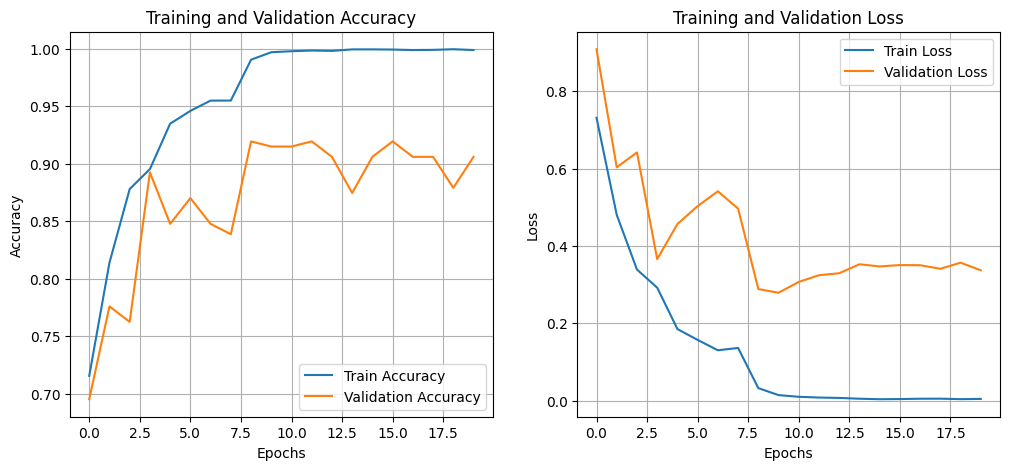

In [4]:

# --- 5. PLOTTING GRAPHS ---
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [5]:

# --- 6. EVALUATION ON TEST SET ---
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

print("\n--- Evaluating on Test Set ---")
y_true, y_pred = evaluate_model(trained_model, test_loader)



--- Evaluating on Test Set ---



Classification Report:
                        precision    recall  f1-score   support

      Cysts_Structural       1.00      0.95      0.98        22
             Dysarthia       1.00      1.00      1.00        42
            Laryngitis       0.86      0.88      0.87        42
           Vox senilis       0.94      0.94      0.94        50
             parkinson       0.96      1.00      0.98        50
spasmodische_dysphonie       0.83      0.75      0.79        20

              accuracy                           0.94       226
             macro avg       0.93      0.92      0.93       226
          weighted avg       0.94      0.94      0.94       226



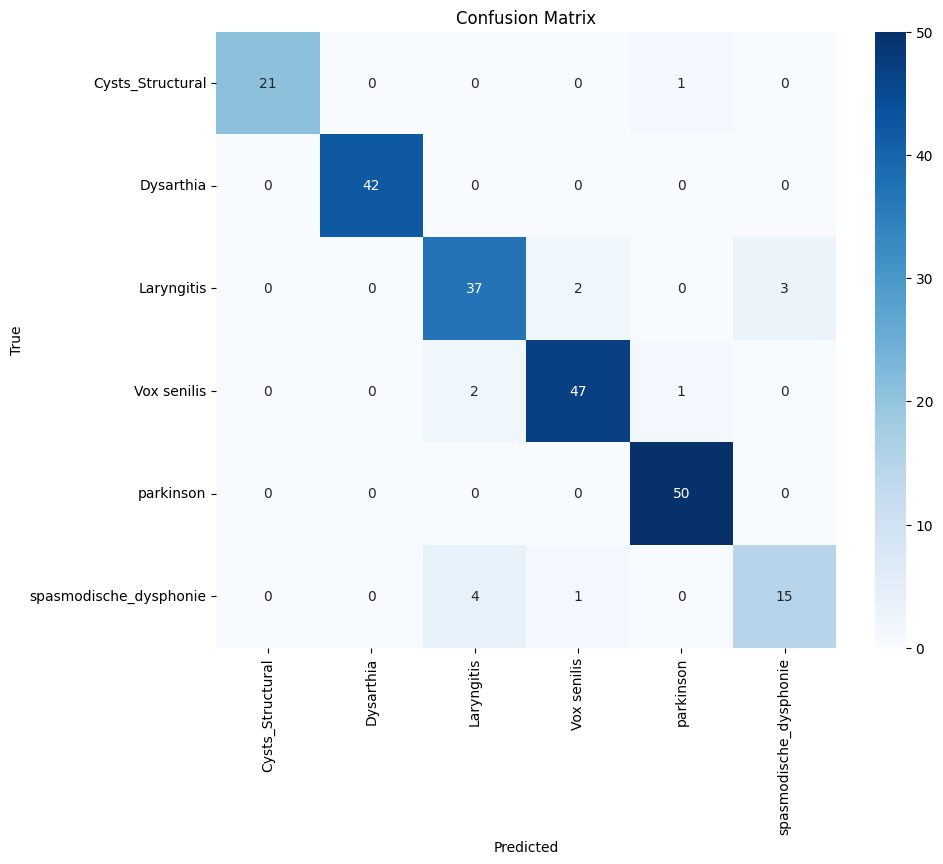

Model saved to resnet34_pathology_speech.pth


In [6]:

# --- 7. METRICS (Confusion Matrix & Classification Report) ---

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# --- 8. SAVE MODEL ---
torch.save(trained_model.state_dict(), "resnet34_pathology_speech.pth")
print("Model saved to resnet34_pathology_speech.pth")